In [1]:
%load_ext watermark


In [2]:
import itertools as it
import os

import matplotlib as mpl
from matplotlib import pyplot as plt
import pandas as pd
from phyloframe import _auxlib as pfa
from phyloframe import legacy as pfl
from pyfonts import load_google_font
from teeplot import teeplot as tp

import pylib


/opt/hostedtoolcache/Python/3.11.15/x64/lib/python3.11/site-packages/alifedata_phyloinformatics_convert/_impl/phytrack_Systematcs.py:7: UserWarning: ImportWarning: phylotrackpy.Systematics import failed; inserting a no-op mock for Systematics. This is likely because phylotrackpy is not installed.
  warnings.warn(


In [3]:
%watermark -diwmuv -iv


Last updated: 2026-03-13T11:25:50.163562+00:00

Python implementation: CPython
Python version       : 3.11.15
IPython version      : 7.31.1

Compiler    : GCC 11.4.0
OS          : Linux
Release     : 6.8.0-1044-azure
Machine     : x86_64
Processor   : x86_64
CPU cores   : 4
Architecture: 64bit

matplotlib: 3.10.0
pandas    : 2.2.3
pylib     : 0.0.0
teeplot   : 1.4.2
phyloframe: 0.2.2

Watermark: 2.4.3



In [4]:
teeplot_subdir = os.environ.get("NOTEBOOK_NAME", "2026-03-04-fossil-clade")
teeplot_subdir


'2026-03-04-fossil-clade'

In [5]:
pfa.seed_random(1)


In [6]:
font = load_google_font("Merriweather", weight=300)
mpl.font_manager.fontManager.addfont(font.get_file())
plt.rcParams["font.family"] = font.get_name()


## Prep Data


In [7]:
df_pure = pfl.alifestd_join_roots(
    pd.read_parquet("https://osf.io/pfvsg/download"),
)
df_pure


,id,dstream_data_id,ancestor_id,dstream_rank,hstrat_differentia_bitwidth,dstream_S,data_hex,genomeFlavor,globalSeed,nCol,...,CEREBRASLIB_TRAITLOGGER_DSTREAM_ALGO_NAME,CEREBRASLIB_HSTRAT_T_DILATION,CEREBRASLIB_HSTRAT_DSTREAM_ALGO_NAME,ASYNC_GA_GENOME_FLAVOR,is_extant,layer,layer_T,position,is_root,is_oldest_root
0,0,9223372036854775807,0,0,1,64,None,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,True,True
1,1,9223372036854775807,0,510,1,64,None,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,False,False
2,2,9223372036854775807,1,1022,1,64,None,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,False,False
3,3,9223372036854775807,2,1534,1,64,None,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,False,False
4,4,9223372036854775807,3,3070,1,64,None,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99950,99950,999556085,99744,151216,1,64,bf7ffeba00024eb10a68ef4ccad354610049ce12,genome_purifyingonly,1.0,755.0,...,steady_algo,32.0,hybrid_0_steady_1_tilted_2_algo,genome_purifyingonly,False,1249.0,8761.0,439435.0,False,False
99951,99951,999555051,97585,151219,1,64,bf7ffeb400024eb40a68ef4cc40779dd0049ce67,genome_purifyingonly,1.0,755.0,...,steady_algo,32.0,hybrid_0_steady_1_tilted_2_algo,genome_purifyingonly,False,1249.0,8761.0,438401.0,False,False
99952,99952,999592311,99337,151222,1,64,bf7ffeb500024eb70a68af4c4cd76dc10049cec3,genome_purifyingonly,1.0,755.0,...,steady_algo,32.0,hybrid_0_steady_1_tilted_2_algo,genome_purifyingonly,False,1249.0,8761.0,475661.0,False,False
99953,99953,999522298,97024,151225,1,64,bf7ffeb400024eba0268ef4c5da3b9c90049cf24,genome_purifyingonly,1.0,755.0,...,steady_algo,32.0,hybrid_0_steady_1_tilted_2_algo,genome_purifyingonly,False,1249.0,8761.0,405648.0,False,False


In [8]:
df_sweep = pfl.alifestd_join_roots(
    pd.read_parquet("https://osf.io/nk69s/download"),
)
df_sweep


,id,dstream_data_id,ancestor_id,dstream_rank,hstrat_differentia_bitwidth,dstream_S,data_hex,genomeFlavor,globalSeed,nCol,...,CEREBRASLIB_TRAITLOGGER_DSTREAM_ALGO_NAME,CEREBRASLIB_HSTRAT_T_DILATION,CEREBRASLIB_HSTRAT_DSTREAM_ALGO_NAME,ASYNC_GA_GENOME_FLAVOR,is_extant,layer,layer_T,position,is_root,is_oldest_root
0,0,9223372036854775807,0,0,1,64,None,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,True,True
1,1,9223372036854775807,0,2046,1,64,None,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,False,False
2,2,9223372036854775807,1,15870,1,64,None,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,False,False
3,3,9223372036854775807,2,16287,1,64,None,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,False,False
4,4,9223372036854775807,3,16383,1,64,None,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99872,99872,999754987,99704,147913,1,64,c9477d70000241cadfb756bb95f5820600483125,genome_purifyingsweep,2.0,755.0,...,steady_algo,32.0,hybrid_0_steady_1_tilted_2_algo,genome_purifyingsweep,False,1249.0,9873.0,638337.0,False,False
99873,99873,999934079,99643,147915,1,64,c9478350000241ccdfb716bb34f586c60048316f,genome_purifyingsweep,2.0,755.0,...,steady_algo,32.0,hybrid_0_steady_1_tilted_2_algo,genome_purifyingsweep,False,1249.0,9873.0,817429.0,False,False
99874,99874,999989329,99507,147918,1,64,c9478cc0000241cfdfb756bb2bf18946004831c1,genome_purifyingsweep,2.0,755.0,...,steady_algo,32.0,hybrid_0_steady_1_tilted_2_algo,genome_purifyingsweep,False,1249.0,9873.0,872679.0,False,False
99875,99875,999919661,99699,147920,1,64,c9477d10000241d1dfb756bb26f594c60048320f,genome_purifyingsweep,2.0,755.0,...,steady_algo,32.0,hybrid_0_steady_1_tilted_2_algo,genome_purifyingsweep,False,1249.0,9873.0,803011.0,False,False


In [9]:
dfs = []
for df in (df_pure, df_sweep):
    df["x"] = df["position"] // df["nCol"]
    df["x_"] = df["x"] / df["nRow"]
    df["y"] = df["position"] % df["nCol"]
    df["y_"] = df["y"] / df["nCol"]

    df["origin_time"] = df["dstream_rank"]

    dfs.append(df)

df_pure, df_sweep = dfs


## Plot Layer Tree


/opt/hostedtoolcache/Python/3.11.15/x64/lib/python3.11/site-packages/phyloframe/legacy/_alifestd_warn_topological_sensitivity.py:35: UserWarning: alifestd_prune_extinct_lineages_asexual performs delete operations that do not update topology-dependent columns, which may be invalidated: ['num_leaves']. Use `origin_time` to recalculate branch lengths for collapsed phylogeny. To silence this warning, use alifestd_drop_topological_sensitivity{_polars} or set HSTRAT_ALIFESTD_WARN_TOPOLOGICAL_SENSITIVITY_SUPPRESS environment variable.
  warnings.warn(
/opt/hostedtoolcache/Python/3.11.15/x64/lib/python3.11/site-packages/phyloframe/legacy/_alifestd_warn_topological_sensitivity.py:35: UserWarning: alifestd_collapse_unifurcations performs delete/update operations that do not update topology-dependent columns, which may be invalidated: ['num_leaves']. Use `origin_time` to recalculate branch lengths for collapsed phylogeny. To silence this warning, use alifestd_drop_topological_sensitivity{_polars}

teeplots/2026-03-04-fossil-clade/layout=vertical+regime=pure+seed=0+viz=draw-ctree+x=x+y=y+ext=.pdf
teeplots/2026-03-04-fossil-clade/layout=vertical+regime=pure+seed=0+viz=draw-ctree+x=x+y=y+ext=.png


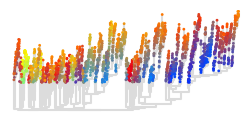

/opt/hostedtoolcache/Python/3.11.15/x64/lib/python3.11/site-packages/phyloframe/legacy/_alifestd_warn_topological_sensitivity.py:35: UserWarning: alifestd_collapse_unifurcations performs delete/update operations that do not update topology-dependent columns, which may be invalidated: ['num_leaves', 'num_children']. Use `origin_time` to recalculate branch lengths for collapsed phylogeny. To silence this warning, use alifestd_drop_topological_sensitivity{_polars} or set HSTRAT_ALIFESTD_WARN_TOPOLOGICAL_SENSITIVITY_SUPPRESS environment variable.
  warnings.warn(


teeplots/2026-03-04-fossil-clade/layout=horizontal+regime=pure+seed=0+viz=draw-ctree+x=x+y=y+ext=.pdf
teeplots/2026-03-04-fossil-clade/layout=horizontal+regime=pure+seed=0+viz=draw-ctree+x=x+y=y+ext=.png


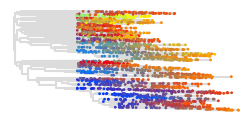

/opt/hostedtoolcache/Python/3.11.15/x64/lib/python3.11/site-packages/phyloframe/legacy/_alifestd_warn_topological_sensitivity.py:35: UserWarning: alifestd_collapse_unifurcations performs delete/update operations that do not update topology-dependent columns, which may be invalidated: ['num_leaves', 'num_children']. Use `origin_time` to recalculate branch lengths for collapsed phylogeny. To silence this warning, use alifestd_drop_topological_sensitivity{_polars} or set HSTRAT_ALIFESTD_WARN_TOPOLOGICAL_SENSITIVITY_SUPPRESS environment variable.
  warnings.warn(


teeplots/2026-03-04-fossil-clade/layout=radial+regime=pure+seed=0+viz=draw-ctree+x=x+y=y+ext=.pdf
teeplots/2026-03-04-fossil-clade/layout=radial+regime=pure+seed=0+viz=draw-ctree+x=x+y=y+ext=.png


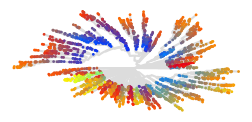

teeplots/2026-03-04-fossil-clade/cmap=bcyr+regime=pure+seed=0+viz=draw-cscatter+x=x+y=y+ext=.pdf
teeplots/2026-03-04-fossil-clade/cmap=bcyr+regime=pure+seed=0+viz=draw-cscatter+x=x+y=y+ext=.png


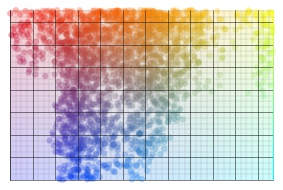

/opt/hostedtoolcache/Python/3.11.15/x64/lib/python3.11/site-packages/phyloframe/legacy/_alifestd_warn_topological_sensitivity.py:35: UserWarning: alifestd_prune_extinct_lineages_asexual performs delete operations that do not update topology-dependent columns, which may be invalidated: ['num_leaves']. Use `origin_time` to recalculate branch lengths for collapsed phylogeny. To silence this warning, use alifestd_drop_topological_sensitivity{_polars} or set HSTRAT_ALIFESTD_WARN_TOPOLOGICAL_SENSITIVITY_SUPPRESS environment variable.
  warnings.warn(
/opt/hostedtoolcache/Python/3.11.15/x64/lib/python3.11/site-packages/phyloframe/legacy/_alifestd_warn_topological_sensitivity.py:35: UserWarning: alifestd_collapse_unifurcations performs delete/update operations that do not update topology-dependent columns, which may be invalidated: ['num_leaves']. Use `origin_time` to recalculate branch lengths for collapsed phylogeny. To silence this warning, use alifestd_drop_topological_sensitivity{_polars}

teeplots/2026-03-04-fossil-clade/layout=vertical+regime=pure+seed=1+viz=draw-ctree+x=x+y=y+ext=.pdf
teeplots/2026-03-04-fossil-clade/layout=vertical+regime=pure+seed=1+viz=draw-ctree+x=x+y=y+ext=.png


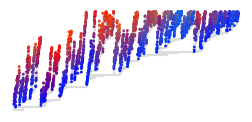

/opt/hostedtoolcache/Python/3.11.15/x64/lib/python3.11/site-packages/phyloframe/legacy/_alifestd_warn_topological_sensitivity.py:35: UserWarning: alifestd_collapse_unifurcations performs delete/update operations that do not update topology-dependent columns, which may be invalidated: ['num_leaves', 'num_children']. Use `origin_time` to recalculate branch lengths for collapsed phylogeny. To silence this warning, use alifestd_drop_topological_sensitivity{_polars} or set HSTRAT_ALIFESTD_WARN_TOPOLOGICAL_SENSITIVITY_SUPPRESS environment variable.
  warnings.warn(


teeplots/2026-03-04-fossil-clade/layout=horizontal+regime=pure+seed=1+viz=draw-ctree+x=x+y=y+ext=.pdf
teeplots/2026-03-04-fossil-clade/layout=horizontal+regime=pure+seed=1+viz=draw-ctree+x=x+y=y+ext=.png


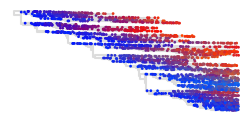

/opt/hostedtoolcache/Python/3.11.15/x64/lib/python3.11/site-packages/phyloframe/legacy/_alifestd_warn_topological_sensitivity.py:35: UserWarning: alifestd_collapse_unifurcations performs delete/update operations that do not update topology-dependent columns, which may be invalidated: ['num_leaves', 'num_children']. Use `origin_time` to recalculate branch lengths for collapsed phylogeny. To silence this warning, use alifestd_drop_topological_sensitivity{_polars} or set HSTRAT_ALIFESTD_WARN_TOPOLOGICAL_SENSITIVITY_SUPPRESS environment variable.
  warnings.warn(


teeplots/2026-03-04-fossil-clade/layout=radial+regime=pure+seed=1+viz=draw-ctree+x=x+y=y+ext=.pdf
teeplots/2026-03-04-fossil-clade/layout=radial+regime=pure+seed=1+viz=draw-ctree+x=x+y=y+ext=.png


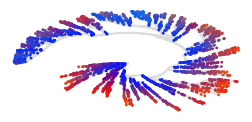

teeplots/2026-03-04-fossil-clade/cmap=bcyr+regime=pure+seed=1+viz=draw-cscatter+x=x+y=y+ext=.pdf
teeplots/2026-03-04-fossil-clade/cmap=bcyr+regime=pure+seed=1+viz=draw-cscatter+x=x+y=y+ext=.png


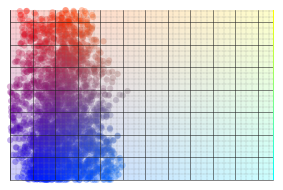

/opt/hostedtoolcache/Python/3.11.15/x64/lib/python3.11/site-packages/phyloframe/legacy/_alifestd_warn_topological_sensitivity.py:35: UserWarning: alifestd_prune_extinct_lineages_asexual performs delete operations that do not update topology-dependent columns, which may be invalidated: ['num_leaves']. Use `origin_time` to recalculate branch lengths for collapsed phylogeny. To silence this warning, use alifestd_drop_topological_sensitivity{_polars} or set HSTRAT_ALIFESTD_WARN_TOPOLOGICAL_SENSITIVITY_SUPPRESS environment variable.
  warnings.warn(
/opt/hostedtoolcache/Python/3.11.15/x64/lib/python3.11/site-packages/phyloframe/legacy/_alifestd_warn_topological_sensitivity.py:35: UserWarning: alifestd_collapse_unifurcations performs delete/update operations that do not update topology-dependent columns, which may be invalidated: ['num_leaves']. Use `origin_time` to recalculate branch lengths for collapsed phylogeny. To silence this warning, use alifestd_drop_topological_sensitivity{_polars}

teeplots/2026-03-04-fossil-clade/layout=vertical+regime=pure+seed=2+viz=draw-ctree+x=x+y=y+ext=.pdf
teeplots/2026-03-04-fossil-clade/layout=vertical+regime=pure+seed=2+viz=draw-ctree+x=x+y=y+ext=.png


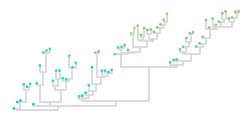

/opt/hostedtoolcache/Python/3.11.15/x64/lib/python3.11/site-packages/phyloframe/legacy/_alifestd_warn_topological_sensitivity.py:35: UserWarning: alifestd_collapse_unifurcations performs delete/update operations that do not update topology-dependent columns, which may be invalidated: ['num_leaves', 'num_children']. Use `origin_time` to recalculate branch lengths for collapsed phylogeny. To silence this warning, use alifestd_drop_topological_sensitivity{_polars} or set HSTRAT_ALIFESTD_WARN_TOPOLOGICAL_SENSITIVITY_SUPPRESS environment variable.
  warnings.warn(


teeplots/2026-03-04-fossil-clade/layout=horizontal+regime=pure+seed=2+viz=draw-ctree+x=x+y=y+ext=.pdf
teeplots/2026-03-04-fossil-clade/layout=horizontal+regime=pure+seed=2+viz=draw-ctree+x=x+y=y+ext=.png


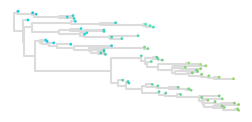

/opt/hostedtoolcache/Python/3.11.15/x64/lib/python3.11/site-packages/phyloframe/legacy/_alifestd_warn_topological_sensitivity.py:35: UserWarning: alifestd_collapse_unifurcations performs delete/update operations that do not update topology-dependent columns, which may be invalidated: ['num_leaves', 'num_children']. Use `origin_time` to recalculate branch lengths for collapsed phylogeny. To silence this warning, use alifestd_drop_topological_sensitivity{_polars} or set HSTRAT_ALIFESTD_WARN_TOPOLOGICAL_SENSITIVITY_SUPPRESS environment variable.
  warnings.warn(


teeplots/2026-03-04-fossil-clade/layout=radial+regime=pure+seed=2+viz=draw-ctree+x=x+y=y+ext=.pdf
teeplots/2026-03-04-fossil-clade/layout=radial+regime=pure+seed=2+viz=draw-ctree+x=x+y=y+ext=.png


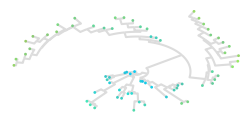

teeplots/2026-03-04-fossil-clade/cmap=bcyr+regime=pure+seed=2+viz=draw-cscatter+x=x+y=y+ext=.pdf
teeplots/2026-03-04-fossil-clade/cmap=bcyr+regime=pure+seed=2+viz=draw-cscatter+x=x+y=y+ext=.png


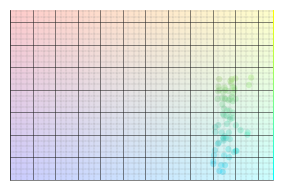

/opt/hostedtoolcache/Python/3.11.15/x64/lib/python3.11/site-packages/phyloframe/legacy/_alifestd_warn_topological_sensitivity.py:35: UserWarning: alifestd_prune_extinct_lineages_asexual performs delete operations that do not update topology-dependent columns, which may be invalidated: ['num_leaves']. Use `origin_time` to recalculate branch lengths for collapsed phylogeny. To silence this warning, use alifestd_drop_topological_sensitivity{_polars} or set HSTRAT_ALIFESTD_WARN_TOPOLOGICAL_SENSITIVITY_SUPPRESS environment variable.
  warnings.warn(
/opt/hostedtoolcache/Python/3.11.15/x64/lib/python3.11/site-packages/phyloframe/legacy/_alifestd_warn_topological_sensitivity.py:35: UserWarning: alifestd_collapse_unifurcations performs delete/update operations that do not update topology-dependent columns, which may be invalidated: ['num_leaves']. Use `origin_time` to recalculate branch lengths for collapsed phylogeny. To silence this warning, use alifestd_drop_topological_sensitivity{_polars}

teeplots/2026-03-04-fossil-clade/layout=vertical+regime=pure+seed=3+viz=draw-ctree+x=x+y=y+ext=.pdf
teeplots/2026-03-04-fossil-clade/layout=vertical+regime=pure+seed=3+viz=draw-ctree+x=x+y=y+ext=.png


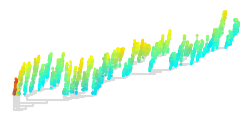

/opt/hostedtoolcache/Python/3.11.15/x64/lib/python3.11/site-packages/phyloframe/legacy/_alifestd_warn_topological_sensitivity.py:35: UserWarning: alifestd_collapse_unifurcations performs delete/update operations that do not update topology-dependent columns, which may be invalidated: ['num_leaves', 'num_children']. Use `origin_time` to recalculate branch lengths for collapsed phylogeny. To silence this warning, use alifestd_drop_topological_sensitivity{_polars} or set HSTRAT_ALIFESTD_WARN_TOPOLOGICAL_SENSITIVITY_SUPPRESS environment variable.
  warnings.warn(


teeplots/2026-03-04-fossil-clade/layout=horizontal+regime=pure+seed=3+viz=draw-ctree+x=x+y=y+ext=.pdf
teeplots/2026-03-04-fossil-clade/layout=horizontal+regime=pure+seed=3+viz=draw-ctree+x=x+y=y+ext=.png


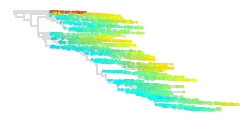

/opt/hostedtoolcache/Python/3.11.15/x64/lib/python3.11/site-packages/phyloframe/legacy/_alifestd_warn_topological_sensitivity.py:35: UserWarning: alifestd_collapse_unifurcations performs delete/update operations that do not update topology-dependent columns, which may be invalidated: ['num_leaves', 'num_children']. Use `origin_time` to recalculate branch lengths for collapsed phylogeny. To silence this warning, use alifestd_drop_topological_sensitivity{_polars} or set HSTRAT_ALIFESTD_WARN_TOPOLOGICAL_SENSITIVITY_SUPPRESS environment variable.
  warnings.warn(


teeplots/2026-03-04-fossil-clade/layout=radial+regime=pure+seed=3+viz=draw-ctree+x=x+y=y+ext=.pdf
teeplots/2026-03-04-fossil-clade/layout=radial+regime=pure+seed=3+viz=draw-ctree+x=x+y=y+ext=.png


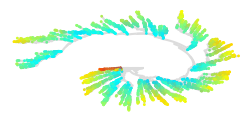

teeplots/2026-03-04-fossil-clade/cmap=bcyr+regime=pure+seed=3+viz=draw-cscatter+x=x+y=y+ext=.pdf
teeplots/2026-03-04-fossil-clade/cmap=bcyr+regime=pure+seed=3+viz=draw-cscatter+x=x+y=y+ext=.png


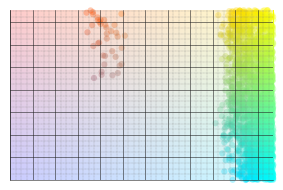

/opt/hostedtoolcache/Python/3.11.15/x64/lib/python3.11/site-packages/phyloframe/legacy/_alifestd_warn_topological_sensitivity.py:35: UserWarning: alifestd_prune_extinct_lineages_asexual performs delete operations that do not update topology-dependent columns, which may be invalidated: ['num_leaves']. Use `origin_time` to recalculate branch lengths for collapsed phylogeny. To silence this warning, use alifestd_drop_topological_sensitivity{_polars} or set HSTRAT_ALIFESTD_WARN_TOPOLOGICAL_SENSITIVITY_SUPPRESS environment variable.
  warnings.warn(
/opt/hostedtoolcache/Python/3.11.15/x64/lib/python3.11/site-packages/phyloframe/legacy/_alifestd_warn_topological_sensitivity.py:35: UserWarning: alifestd_collapse_unifurcations performs delete/update operations that do not update topology-dependent columns, which may be invalidated: ['num_leaves']. Use `origin_time` to recalculate branch lengths for collapsed phylogeny. To silence this warning, use alifestd_drop_topological_sensitivity{_polars}

teeplots/2026-03-04-fossil-clade/layout=vertical+regime=pure+seed=4+viz=draw-ctree+x=x+y=y+ext=.pdf
teeplots/2026-03-04-fossil-clade/layout=vertical+regime=pure+seed=4+viz=draw-ctree+x=x+y=y+ext=.png


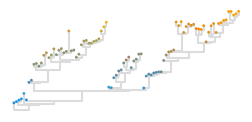

/opt/hostedtoolcache/Python/3.11.15/x64/lib/python3.11/site-packages/phyloframe/legacy/_alifestd_warn_topological_sensitivity.py:35: UserWarning: alifestd_collapse_unifurcations performs delete/update operations that do not update topology-dependent columns, which may be invalidated: ['num_leaves', 'num_children']. Use `origin_time` to recalculate branch lengths for collapsed phylogeny. To silence this warning, use alifestd_drop_topological_sensitivity{_polars} or set HSTRAT_ALIFESTD_WARN_TOPOLOGICAL_SENSITIVITY_SUPPRESS environment variable.
  warnings.warn(


teeplots/2026-03-04-fossil-clade/layout=horizontal+regime=pure+seed=4+viz=draw-ctree+x=x+y=y+ext=.pdf
teeplots/2026-03-04-fossil-clade/layout=horizontal+regime=pure+seed=4+viz=draw-ctree+x=x+y=y+ext=.png


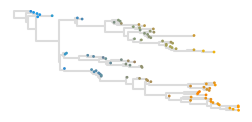

/opt/hostedtoolcache/Python/3.11.15/x64/lib/python3.11/site-packages/phyloframe/legacy/_alifestd_warn_topological_sensitivity.py:35: UserWarning: alifestd_collapse_unifurcations performs delete/update operations that do not update topology-dependent columns, which may be invalidated: ['num_leaves', 'num_children']. Use `origin_time` to recalculate branch lengths for collapsed phylogeny. To silence this warning, use alifestd_drop_topological_sensitivity{_polars} or set HSTRAT_ALIFESTD_WARN_TOPOLOGICAL_SENSITIVITY_SUPPRESS environment variable.
  warnings.warn(


teeplots/2026-03-04-fossil-clade/layout=radial+regime=pure+seed=4+viz=draw-ctree+x=x+y=y+ext=.pdf
teeplots/2026-03-04-fossil-clade/layout=radial+regime=pure+seed=4+viz=draw-ctree+x=x+y=y+ext=.png


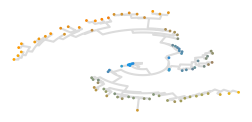

teeplots/2026-03-04-fossil-clade/cmap=bcyr+regime=pure+seed=4+viz=draw-cscatter+x=x+y=y+ext=.pdf
teeplots/2026-03-04-fossil-clade/cmap=bcyr+regime=pure+seed=4+viz=draw-cscatter+x=x+y=y+ext=.png


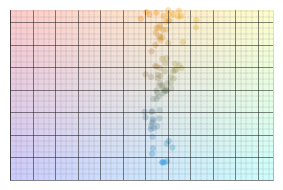

/opt/hostedtoolcache/Python/3.11.15/x64/lib/python3.11/site-packages/phyloframe/legacy/_alifestd_warn_topological_sensitivity.py:35: UserWarning: alifestd_prune_extinct_lineages_asexual performs delete operations that do not update topology-dependent columns, which may be invalidated: ['num_leaves']. Use `origin_time` to recalculate branch lengths for collapsed phylogeny. To silence this warning, use alifestd_drop_topological_sensitivity{_polars} or set HSTRAT_ALIFESTD_WARN_TOPOLOGICAL_SENSITIVITY_SUPPRESS environment variable.
  warnings.warn(
/opt/hostedtoolcache/Python/3.11.15/x64/lib/python3.11/site-packages/phyloframe/legacy/_alifestd_warn_topological_sensitivity.py:35: UserWarning: alifestd_collapse_unifurcations performs delete/update operations that do not update topology-dependent columns, which may be invalidated: ['num_leaves']. Use `origin_time` to recalculate branch lengths for collapsed phylogeny. To silence this warning, use alifestd_drop_topological_sensitivity{_polars}

teeplots/2026-03-04-fossil-clade/layout=vertical+regime=pure+seed=5+viz=draw-ctree+x=x+y=y+ext=.pdf
teeplots/2026-03-04-fossil-clade/layout=vertical+regime=pure+seed=5+viz=draw-ctree+x=x+y=y+ext=.png


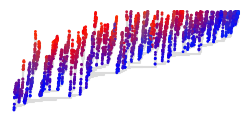

/opt/hostedtoolcache/Python/3.11.15/x64/lib/python3.11/site-packages/phyloframe/legacy/_alifestd_warn_topological_sensitivity.py:35: UserWarning: alifestd_collapse_unifurcations performs delete/update operations that do not update topology-dependent columns, which may be invalidated: ['num_leaves', 'num_children']. Use `origin_time` to recalculate branch lengths for collapsed phylogeny. To silence this warning, use alifestd_drop_topological_sensitivity{_polars} or set HSTRAT_ALIFESTD_WARN_TOPOLOGICAL_SENSITIVITY_SUPPRESS environment variable.
  warnings.warn(


teeplots/2026-03-04-fossil-clade/layout=horizontal+regime=pure+seed=5+viz=draw-ctree+x=x+y=y+ext=.pdf
teeplots/2026-03-04-fossil-clade/layout=horizontal+regime=pure+seed=5+viz=draw-ctree+x=x+y=y+ext=.png


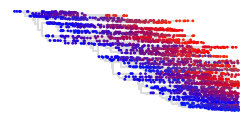

/opt/hostedtoolcache/Python/3.11.15/x64/lib/python3.11/site-packages/phyloframe/legacy/_alifestd_warn_topological_sensitivity.py:35: UserWarning: alifestd_collapse_unifurcations performs delete/update operations that do not update topology-dependent columns, which may be invalidated: ['num_leaves', 'num_children']. Use `origin_time` to recalculate branch lengths for collapsed phylogeny. To silence this warning, use alifestd_drop_topological_sensitivity{_polars} or set HSTRAT_ALIFESTD_WARN_TOPOLOGICAL_SENSITIVITY_SUPPRESS environment variable.
  warnings.warn(


teeplots/2026-03-04-fossil-clade/layout=radial+regime=pure+seed=5+viz=draw-ctree+x=x+y=y+ext=.pdf
teeplots/2026-03-04-fossil-clade/layout=radial+regime=pure+seed=5+viz=draw-ctree+x=x+y=y+ext=.png


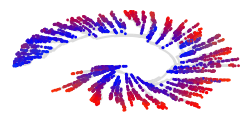

teeplots/2026-03-04-fossil-clade/cmap=bcyr+regime=pure+seed=5+viz=draw-cscatter+x=x+y=y+ext=.pdf
teeplots/2026-03-04-fossil-clade/cmap=bcyr+regime=pure+seed=5+viz=draw-cscatter+x=x+y=y+ext=.png


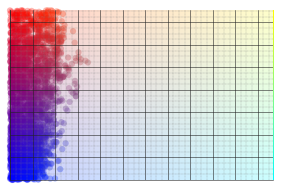

/opt/hostedtoolcache/Python/3.11.15/x64/lib/python3.11/site-packages/phyloframe/legacy/_alifestd_warn_topological_sensitivity.py:35: UserWarning: alifestd_prune_extinct_lineages_asexual performs delete operations that do not update topology-dependent columns, which may be invalidated: ['num_leaves']. Use `origin_time` to recalculate branch lengths for collapsed phylogeny. To silence this warning, use alifestd_drop_topological_sensitivity{_polars} or set HSTRAT_ALIFESTD_WARN_TOPOLOGICAL_SENSITIVITY_SUPPRESS environment variable.
  warnings.warn(
/opt/hostedtoolcache/Python/3.11.15/x64/lib/python3.11/site-packages/phyloframe/legacy/_alifestd_warn_topological_sensitivity.py:35: UserWarning: alifestd_collapse_unifurcations performs delete/update operations that do not update topology-dependent columns, which may be invalidated: ['num_leaves']. Use `origin_time` to recalculate branch lengths for collapsed phylogeny. To silence this warning, use alifestd_drop_topological_sensitivity{_polars}

teeplots/2026-03-04-fossil-clade/layout=vertical+regime=pure+seed=6+viz=draw-ctree+x=x+y=y+ext=.pdf
teeplots/2026-03-04-fossil-clade/layout=vertical+regime=pure+seed=6+viz=draw-ctree+x=x+y=y+ext=.png


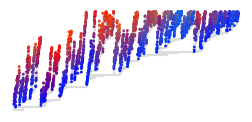

/opt/hostedtoolcache/Python/3.11.15/x64/lib/python3.11/site-packages/phyloframe/legacy/_alifestd_warn_topological_sensitivity.py:35: UserWarning: alifestd_collapse_unifurcations performs delete/update operations that do not update topology-dependent columns, which may be invalidated: ['num_leaves', 'num_children']. Use `origin_time` to recalculate branch lengths for collapsed phylogeny. To silence this warning, use alifestd_drop_topological_sensitivity{_polars} or set HSTRAT_ALIFESTD_WARN_TOPOLOGICAL_SENSITIVITY_SUPPRESS environment variable.
  warnings.warn(


teeplots/2026-03-04-fossil-clade/layout=horizontal+regime=pure+seed=6+viz=draw-ctree+x=x+y=y+ext=.pdf
teeplots/2026-03-04-fossil-clade/layout=horizontal+regime=pure+seed=6+viz=draw-ctree+x=x+y=y+ext=.png


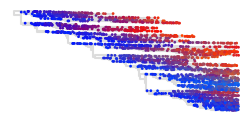

/opt/hostedtoolcache/Python/3.11.15/x64/lib/python3.11/site-packages/phyloframe/legacy/_alifestd_warn_topological_sensitivity.py:35: UserWarning: alifestd_collapse_unifurcations performs delete/update operations that do not update topology-dependent columns, which may be invalidated: ['num_leaves', 'num_children']. Use `origin_time` to recalculate branch lengths for collapsed phylogeny. To silence this warning, use alifestd_drop_topological_sensitivity{_polars} or set HSTRAT_ALIFESTD_WARN_TOPOLOGICAL_SENSITIVITY_SUPPRESS environment variable.
  warnings.warn(


teeplots/2026-03-04-fossil-clade/layout=radial+regime=pure+seed=6+viz=draw-ctree+x=x+y=y+ext=.pdf
teeplots/2026-03-04-fossil-clade/layout=radial+regime=pure+seed=6+viz=draw-ctree+x=x+y=y+ext=.png


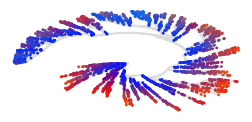

teeplots/2026-03-04-fossil-clade/cmap=bcyr+regime=pure+seed=6+viz=draw-cscatter+x=x+y=y+ext=.pdf
teeplots/2026-03-04-fossil-clade/cmap=bcyr+regime=pure+seed=6+viz=draw-cscatter+x=x+y=y+ext=.png


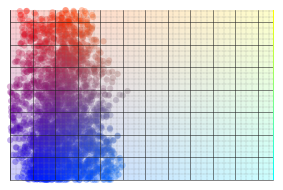

/opt/hostedtoolcache/Python/3.11.15/x64/lib/python3.11/site-packages/phyloframe/legacy/_alifestd_warn_topological_sensitivity.py:35: UserWarning: alifestd_prune_extinct_lineages_asexual performs delete operations that do not update topology-dependent columns, which may be invalidated: ['num_leaves']. Use `origin_time` to recalculate branch lengths for collapsed phylogeny. To silence this warning, use alifestd_drop_topological_sensitivity{_polars} or set HSTRAT_ALIFESTD_WARN_TOPOLOGICAL_SENSITIVITY_SUPPRESS environment variable.
  warnings.warn(
/opt/hostedtoolcache/Python/3.11.15/x64/lib/python3.11/site-packages/phyloframe/legacy/_alifestd_warn_topological_sensitivity.py:35: UserWarning: alifestd_collapse_unifurcations performs delete/update operations that do not update topology-dependent columns, which may be invalidated: ['num_leaves']. Use `origin_time` to recalculate branch lengths for collapsed phylogeny. To silence this warning, use alifestd_drop_topological_sensitivity{_polars}

teeplots/2026-03-04-fossil-clade/layout=vertical+regime=pure+seed=7+viz=draw-ctree+x=x+y=y+ext=.pdf
teeplots/2026-03-04-fossil-clade/layout=vertical+regime=pure+seed=7+viz=draw-ctree+x=x+y=y+ext=.png


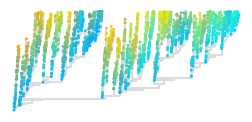

/opt/hostedtoolcache/Python/3.11.15/x64/lib/python3.11/site-packages/phyloframe/legacy/_alifestd_warn_topological_sensitivity.py:35: UserWarning: alifestd_collapse_unifurcations performs delete/update operations that do not update topology-dependent columns, which may be invalidated: ['num_leaves', 'num_children']. Use `origin_time` to recalculate branch lengths for collapsed phylogeny. To silence this warning, use alifestd_drop_topological_sensitivity{_polars} or set HSTRAT_ALIFESTD_WARN_TOPOLOGICAL_SENSITIVITY_SUPPRESS environment variable.
  warnings.warn(


teeplots/2026-03-04-fossil-clade/layout=horizontal+regime=pure+seed=7+viz=draw-ctree+x=x+y=y+ext=.pdf
teeplots/2026-03-04-fossil-clade/layout=horizontal+regime=pure+seed=7+viz=draw-ctree+x=x+y=y+ext=.png


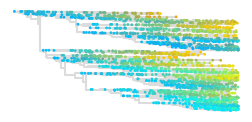

/opt/hostedtoolcache/Python/3.11.15/x64/lib/python3.11/site-packages/phyloframe/legacy/_alifestd_warn_topological_sensitivity.py:35: UserWarning: alifestd_collapse_unifurcations performs delete/update operations that do not update topology-dependent columns, which may be invalidated: ['num_leaves', 'num_children']. Use `origin_time` to recalculate branch lengths for collapsed phylogeny. To silence this warning, use alifestd_drop_topological_sensitivity{_polars} or set HSTRAT_ALIFESTD_WARN_TOPOLOGICAL_SENSITIVITY_SUPPRESS environment variable.
  warnings.warn(


teeplots/2026-03-04-fossil-clade/layout=radial+regime=pure+seed=7+viz=draw-ctree+x=x+y=y+ext=.pdf
teeplots/2026-03-04-fossil-clade/layout=radial+regime=pure+seed=7+viz=draw-ctree+x=x+y=y+ext=.png


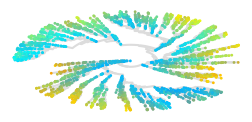

teeplots/2026-03-04-fossil-clade/cmap=bcyr+regime=pure+seed=7+viz=draw-cscatter+x=x+y=y+ext=.pdf
teeplots/2026-03-04-fossil-clade/cmap=bcyr+regime=pure+seed=7+viz=draw-cscatter+x=x+y=y+ext=.png


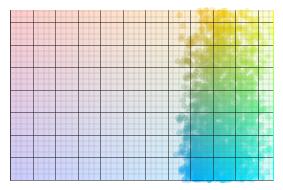

/opt/hostedtoolcache/Python/3.11.15/x64/lib/python3.11/site-packages/phyloframe/legacy/_alifestd_warn_topological_sensitivity.py:35: UserWarning: alifestd_prune_extinct_lineages_asexual performs delete operations that do not update topology-dependent columns, which may be invalidated: ['num_leaves']. Use `origin_time` to recalculate branch lengths for collapsed phylogeny. To silence this warning, use alifestd_drop_topological_sensitivity{_polars} or set HSTRAT_ALIFESTD_WARN_TOPOLOGICAL_SENSITIVITY_SUPPRESS environment variable.
  warnings.warn(
/opt/hostedtoolcache/Python/3.11.15/x64/lib/python3.11/site-packages/phyloframe/legacy/_alifestd_warn_topological_sensitivity.py:35: UserWarning: alifestd_collapse_unifurcations performs delete/update operations that do not update topology-dependent columns, which may be invalidated: ['num_leaves']. Use `origin_time` to recalculate branch lengths for collapsed phylogeny. To silence this warning, use alifestd_drop_topological_sensitivity{_polars}

teeplots/2026-03-04-fossil-clade/layout=vertical+regime=pure+seed=8+viz=draw-ctree+x=x+y=y+ext=.pdf
teeplots/2026-03-04-fossil-clade/layout=vertical+regime=pure+seed=8+viz=draw-ctree+x=x+y=y+ext=.png


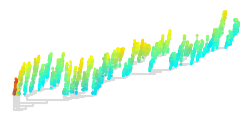

/opt/hostedtoolcache/Python/3.11.15/x64/lib/python3.11/site-packages/phyloframe/legacy/_alifestd_warn_topological_sensitivity.py:35: UserWarning: alifestd_collapse_unifurcations performs delete/update operations that do not update topology-dependent columns, which may be invalidated: ['num_leaves', 'num_children']. Use `origin_time` to recalculate branch lengths for collapsed phylogeny. To silence this warning, use alifestd_drop_topological_sensitivity{_polars} or set HSTRAT_ALIFESTD_WARN_TOPOLOGICAL_SENSITIVITY_SUPPRESS environment variable.
  warnings.warn(


teeplots/2026-03-04-fossil-clade/layout=horizontal+regime=pure+seed=8+viz=draw-ctree+x=x+y=y+ext=.pdf
teeplots/2026-03-04-fossil-clade/layout=horizontal+regime=pure+seed=8+viz=draw-ctree+x=x+y=y+ext=.png


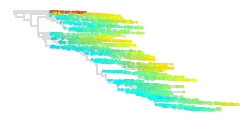

/opt/hostedtoolcache/Python/3.11.15/x64/lib/python3.11/site-packages/phyloframe/legacy/_alifestd_warn_topological_sensitivity.py:35: UserWarning: alifestd_collapse_unifurcations performs delete/update operations that do not update topology-dependent columns, which may be invalidated: ['num_leaves', 'num_children']. Use `origin_time` to recalculate branch lengths for collapsed phylogeny. To silence this warning, use alifestd_drop_topological_sensitivity{_polars} or set HSTRAT_ALIFESTD_WARN_TOPOLOGICAL_SENSITIVITY_SUPPRESS environment variable.
  warnings.warn(


teeplots/2026-03-04-fossil-clade/layout=radial+regime=pure+seed=8+viz=draw-ctree+x=x+y=y+ext=.pdf
teeplots/2026-03-04-fossil-clade/layout=radial+regime=pure+seed=8+viz=draw-ctree+x=x+y=y+ext=.png


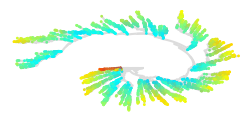

teeplots/2026-03-04-fossil-clade/cmap=bcyr+regime=pure+seed=8+viz=draw-cscatter+x=x+y=y+ext=.pdf
teeplots/2026-03-04-fossil-clade/cmap=bcyr+regime=pure+seed=8+viz=draw-cscatter+x=x+y=y+ext=.png


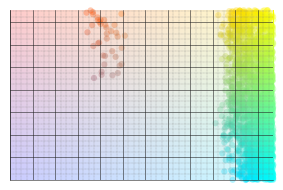

/opt/hostedtoolcache/Python/3.11.15/x64/lib/python3.11/site-packages/phyloframe/legacy/_alifestd_warn_topological_sensitivity.py:35: UserWarning: alifestd_prune_extinct_lineages_asexual performs delete operations that do not update topology-dependent columns, which may be invalidated: ['num_leaves']. Use `origin_time` to recalculate branch lengths for collapsed phylogeny. To silence this warning, use alifestd_drop_topological_sensitivity{_polars} or set HSTRAT_ALIFESTD_WARN_TOPOLOGICAL_SENSITIVITY_SUPPRESS environment variable.
  warnings.warn(
/opt/hostedtoolcache/Python/3.11.15/x64/lib/python3.11/site-packages/phyloframe/legacy/_alifestd_warn_topological_sensitivity.py:35: UserWarning: alifestd_collapse_unifurcations performs delete/update operations that do not update topology-dependent columns, which may be invalidated: ['num_leaves']. Use `origin_time` to recalculate branch lengths for collapsed phylogeny. To silence this warning, use alifestd_drop_topological_sensitivity{_polars}

teeplots/2026-03-04-fossil-clade/layout=vertical+regime=pure+seed=9+viz=draw-ctree+x=x+y=y+ext=.pdf
teeplots/2026-03-04-fossil-clade/layout=vertical+regime=pure+seed=9+viz=draw-ctree+x=x+y=y+ext=.png


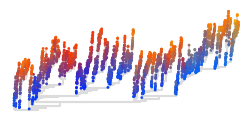

/opt/hostedtoolcache/Python/3.11.15/x64/lib/python3.11/site-packages/phyloframe/legacy/_alifestd_warn_topological_sensitivity.py:35: UserWarning: alifestd_collapse_unifurcations performs delete/update operations that do not update topology-dependent columns, which may be invalidated: ['num_leaves', 'num_children']. Use `origin_time` to recalculate branch lengths for collapsed phylogeny. To silence this warning, use alifestd_drop_topological_sensitivity{_polars} or set HSTRAT_ALIFESTD_WARN_TOPOLOGICAL_SENSITIVITY_SUPPRESS environment variable.
  warnings.warn(


teeplots/2026-03-04-fossil-clade/layout=horizontal+regime=pure+seed=9+viz=draw-ctree+x=x+y=y+ext=.pdf
teeplots/2026-03-04-fossil-clade/layout=horizontal+regime=pure+seed=9+viz=draw-ctree+x=x+y=y+ext=.png


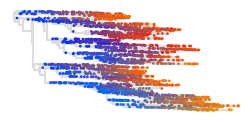

/opt/hostedtoolcache/Python/3.11.15/x64/lib/python3.11/site-packages/phyloframe/legacy/_alifestd_warn_topological_sensitivity.py:35: UserWarning: alifestd_collapse_unifurcations performs delete/update operations that do not update topology-dependent columns, which may be invalidated: ['num_leaves', 'num_children']. Use `origin_time` to recalculate branch lengths for collapsed phylogeny. To silence this warning, use alifestd_drop_topological_sensitivity{_polars} or set HSTRAT_ALIFESTD_WARN_TOPOLOGICAL_SENSITIVITY_SUPPRESS environment variable.
  warnings.warn(


teeplots/2026-03-04-fossil-clade/layout=radial+regime=pure+seed=9+viz=draw-ctree+x=x+y=y+ext=.pdf
teeplots/2026-03-04-fossil-clade/layout=radial+regime=pure+seed=9+viz=draw-ctree+x=x+y=y+ext=.png


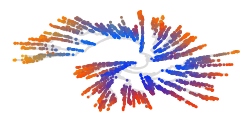

teeplots/2026-03-04-fossil-clade/cmap=bcyr+regime=pure+seed=9+viz=draw-cscatter+x=x+y=y+ext=.pdf
teeplots/2026-03-04-fossil-clade/cmap=bcyr+regime=pure+seed=9+viz=draw-cscatter+x=x+y=y+ext=.png


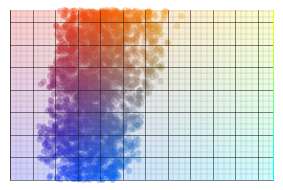

/opt/hostedtoolcache/Python/3.11.15/x64/lib/python3.11/site-packages/phyloframe/legacy/_alifestd_warn_topological_sensitivity.py:35: UserWarning: alifestd_prune_extinct_lineages_asexual performs delete operations that do not update topology-dependent columns, which may be invalidated: ['num_leaves']. Use `origin_time` to recalculate branch lengths for collapsed phylogeny. To silence this warning, use alifestd_drop_topological_sensitivity{_polars} or set HSTRAT_ALIFESTD_WARN_TOPOLOGICAL_SENSITIVITY_SUPPRESS environment variable.
  warnings.warn(
/opt/hostedtoolcache/Python/3.11.15/x64/lib/python3.11/site-packages/phyloframe/legacy/_alifestd_warn_topological_sensitivity.py:35: UserWarning: alifestd_collapse_unifurcations performs delete/update operations that do not update topology-dependent columns, which may be invalidated: ['num_leaves']. Use `origin_time` to recalculate branch lengths for collapsed phylogeny. To silence this warning, use alifestd_drop_topological_sensitivity{_polars}

teeplots/2026-03-04-fossil-clade/layout=vertical+regime=sweep+seed=0+viz=draw-ctree+x=x+y=y+ext=.pdf
teeplots/2026-03-04-fossil-clade/layout=vertical+regime=sweep+seed=0+viz=draw-ctree+x=x+y=y+ext=.png


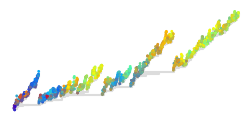

/opt/hostedtoolcache/Python/3.11.15/x64/lib/python3.11/site-packages/phyloframe/legacy/_alifestd_warn_topological_sensitivity.py:35: UserWarning: alifestd_collapse_unifurcations performs delete/update operations that do not update topology-dependent columns, which may be invalidated: ['num_leaves', 'num_children']. Use `origin_time` to recalculate branch lengths for collapsed phylogeny. To silence this warning, use alifestd_drop_topological_sensitivity{_polars} or set HSTRAT_ALIFESTD_WARN_TOPOLOGICAL_SENSITIVITY_SUPPRESS environment variable.
  warnings.warn(


teeplots/2026-03-04-fossil-clade/layout=horizontal+regime=sweep+seed=0+viz=draw-ctree+x=x+y=y+ext=.pdf
teeplots/2026-03-04-fossil-clade/layout=horizontal+regime=sweep+seed=0+viz=draw-ctree+x=x+y=y+ext=.png


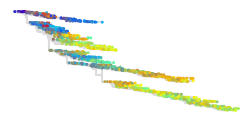

/opt/hostedtoolcache/Python/3.11.15/x64/lib/python3.11/site-packages/phyloframe/legacy/_alifestd_warn_topological_sensitivity.py:35: UserWarning: alifestd_collapse_unifurcations performs delete/update operations that do not update topology-dependent columns, which may be invalidated: ['num_leaves', 'num_children']. Use `origin_time` to recalculate branch lengths for collapsed phylogeny. To silence this warning, use alifestd_drop_topological_sensitivity{_polars} or set HSTRAT_ALIFESTD_WARN_TOPOLOGICAL_SENSITIVITY_SUPPRESS environment variable.
  warnings.warn(


teeplots/2026-03-04-fossil-clade/layout=radial+regime=sweep+seed=0+viz=draw-ctree+x=x+y=y+ext=.pdf
teeplots/2026-03-04-fossil-clade/layout=radial+regime=sweep+seed=0+viz=draw-ctree+x=x+y=y+ext=.png


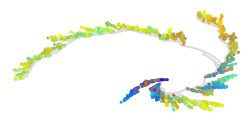

teeplots/2026-03-04-fossil-clade/cmap=bcyr+regime=sweep+seed=0+viz=draw-cscatter+x=x+y=y+ext=.pdf
teeplots/2026-03-04-fossil-clade/cmap=bcyr+regime=sweep+seed=0+viz=draw-cscatter+x=x+y=y+ext=.png


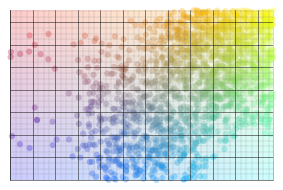

teeplots/2026-03-04-fossil-clade/layout=vertical+regime=sweep+seed=1+viz=draw-ctree+x=x+y=y+ext=.pdf
teeplots/2026-03-04-fossil-clade/layout=vertical+regime=sweep+seed=1+viz=draw-ctree+x=x+y=y+ext=.png


/opt/hostedtoolcache/Python/3.11.15/x64/lib/python3.11/site-packages/phyloframe/legacy/_alifestd_warn_topological_sensitivity.py:35: UserWarning: alifestd_prune_extinct_lineages_asexual performs delete operations that do not update topology-dependent columns, which may be invalidated: ['num_leaves']. Use `origin_time` to recalculate branch lengths for collapsed phylogeny. To silence this warning, use alifestd_drop_topological_sensitivity{_polars} or set HSTRAT_ALIFESTD_WARN_TOPOLOGICAL_SENSITIVITY_SUPPRESS environment variable.
  warnings.warn(
/opt/hostedtoolcache/Python/3.11.15/x64/lib/python3.11/site-packages/phyloframe/legacy/_alifestd_warn_topological_sensitivity.py:35: UserWarning: alifestd_collapse_unifurcations performs delete/update operations that do not update topology-dependent columns, which may be invalidated: ['num_leaves']. Use `origin_time` to recalculate branch lengths for collapsed phylogeny. To silence this warning, use alifestd_drop_topological_sensitivity{_polars}

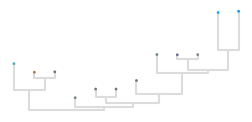

/opt/hostedtoolcache/Python/3.11.15/x64/lib/python3.11/site-packages/phyloframe/legacy/_alifestd_warn_topological_sensitivity.py:35: UserWarning: alifestd_collapse_unifurcations performs delete/update operations that do not update topology-dependent columns, which may be invalidated: ['num_leaves', 'num_children']. Use `origin_time` to recalculate branch lengths for collapsed phylogeny. To silence this warning, use alifestd_drop_topological_sensitivity{_polars} or set HSTRAT_ALIFESTD_WARN_TOPOLOGICAL_SENSITIVITY_SUPPRESS environment variable.
  warnings.warn(


teeplots/2026-03-04-fossil-clade/layout=horizontal+regime=sweep+seed=1+viz=draw-ctree+x=x+y=y+ext=.pdf
teeplots/2026-03-04-fossil-clade/layout=horizontal+regime=sweep+seed=1+viz=draw-ctree+x=x+y=y+ext=.png


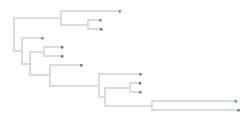

/opt/hostedtoolcache/Python/3.11.15/x64/lib/python3.11/site-packages/phyloframe/legacy/_alifestd_warn_topological_sensitivity.py:35: UserWarning: alifestd_collapse_unifurcations performs delete/update operations that do not update topology-dependent columns, which may be invalidated: ['num_leaves', 'num_children']. Use `origin_time` to recalculate branch lengths for collapsed phylogeny. To silence this warning, use alifestd_drop_topological_sensitivity{_polars} or set HSTRAT_ALIFESTD_WARN_TOPOLOGICAL_SENSITIVITY_SUPPRESS environment variable.
  warnings.warn(


teeplots/2026-03-04-fossil-clade/layout=radial+regime=sweep+seed=1+viz=draw-ctree+x=x+y=y+ext=.pdf
teeplots/2026-03-04-fossil-clade/layout=radial+regime=sweep+seed=1+viz=draw-ctree+x=x+y=y+ext=.png


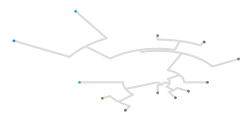

teeplots/2026-03-04-fossil-clade/cmap=bcyr+regime=sweep+seed=1+viz=draw-cscatter+x=x+y=y+ext=.pdf
teeplots/2026-03-04-fossil-clade/cmap=bcyr+regime=sweep+seed=1+viz=draw-cscatter+x=x+y=y+ext=.png


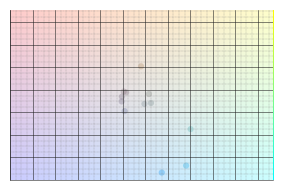

/opt/hostedtoolcache/Python/3.11.15/x64/lib/python3.11/site-packages/phyloframe/legacy/_alifestd_warn_topological_sensitivity.py:35: UserWarning: alifestd_prune_extinct_lineages_asexual performs delete operations that do not update topology-dependent columns, which may be invalidated: ['num_leaves']. Use `origin_time` to recalculate branch lengths for collapsed phylogeny. To silence this warning, use alifestd_drop_topological_sensitivity{_polars} or set HSTRAT_ALIFESTD_WARN_TOPOLOGICAL_SENSITIVITY_SUPPRESS environment variable.
  warnings.warn(
/opt/hostedtoolcache/Python/3.11.15/x64/lib/python3.11/site-packages/phyloframe/legacy/_alifestd_warn_topological_sensitivity.py:35: UserWarning: alifestd_collapse_unifurcations performs delete/update operations that do not update topology-dependent columns, which may be invalidated: ['num_leaves']. Use `origin_time` to recalculate branch lengths for collapsed phylogeny. To silence this warning, use alifestd_drop_topological_sensitivity{_polars}

teeplots/2026-03-04-fossil-clade/layout=vertical+regime=sweep+seed=2+viz=draw-ctree+x=x+y=y+ext=.pdf
teeplots/2026-03-04-fossil-clade/layout=vertical+regime=sweep+seed=2+viz=draw-ctree+x=x+y=y+ext=.png


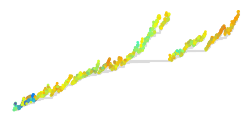

/opt/hostedtoolcache/Python/3.11.15/x64/lib/python3.11/site-packages/phyloframe/legacy/_alifestd_warn_topological_sensitivity.py:35: UserWarning: alifestd_collapse_unifurcations performs delete/update operations that do not update topology-dependent columns, which may be invalidated: ['num_leaves', 'num_children']. Use `origin_time` to recalculate branch lengths for collapsed phylogeny. To silence this warning, use alifestd_drop_topological_sensitivity{_polars} or set HSTRAT_ALIFESTD_WARN_TOPOLOGICAL_SENSITIVITY_SUPPRESS environment variable.
  warnings.warn(


teeplots/2026-03-04-fossil-clade/layout=horizontal+regime=sweep+seed=2+viz=draw-ctree+x=x+y=y+ext=.pdf
teeplots/2026-03-04-fossil-clade/layout=horizontal+regime=sweep+seed=2+viz=draw-ctree+x=x+y=y+ext=.png


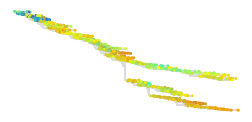

/opt/hostedtoolcache/Python/3.11.15/x64/lib/python3.11/site-packages/phyloframe/legacy/_alifestd_warn_topological_sensitivity.py:35: UserWarning: alifestd_collapse_unifurcations performs delete/update operations that do not update topology-dependent columns, which may be invalidated: ['num_leaves', 'num_children']. Use `origin_time` to recalculate branch lengths for collapsed phylogeny. To silence this warning, use alifestd_drop_topological_sensitivity{_polars} or set HSTRAT_ALIFESTD_WARN_TOPOLOGICAL_SENSITIVITY_SUPPRESS environment variable.
  warnings.warn(


teeplots/2026-03-04-fossil-clade/layout=radial+regime=sweep+seed=2+viz=draw-ctree+x=x+y=y+ext=.pdf
teeplots/2026-03-04-fossil-clade/layout=radial+regime=sweep+seed=2+viz=draw-ctree+x=x+y=y+ext=.png


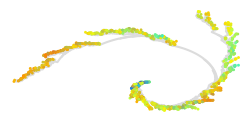

teeplots/2026-03-04-fossil-clade/cmap=bcyr+regime=sweep+seed=2+viz=draw-cscatter+x=x+y=y+ext=.pdf
teeplots/2026-03-04-fossil-clade/cmap=bcyr+regime=sweep+seed=2+viz=draw-cscatter+x=x+y=y+ext=.png


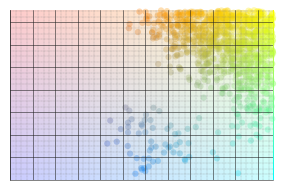

/opt/hostedtoolcache/Python/3.11.15/x64/lib/python3.11/site-packages/phyloframe/legacy/_alifestd_warn_topological_sensitivity.py:35: UserWarning: alifestd_prune_extinct_lineages_asexual performs delete operations that do not update topology-dependent columns, which may be invalidated: ['num_leaves']. Use `origin_time` to recalculate branch lengths for collapsed phylogeny. To silence this warning, use alifestd_drop_topological_sensitivity{_polars} or set HSTRAT_ALIFESTD_WARN_TOPOLOGICAL_SENSITIVITY_SUPPRESS environment variable.
  warnings.warn(
/opt/hostedtoolcache/Python/3.11.15/x64/lib/python3.11/site-packages/phyloframe/legacy/_alifestd_warn_topological_sensitivity.py:35: UserWarning: alifestd_collapse_unifurcations performs delete/update operations that do not update topology-dependent columns, which may be invalidated: ['num_leaves']. Use `origin_time` to recalculate branch lengths for collapsed phylogeny. To silence this warning, use alifestd_drop_topological_sensitivity{_polars}

teeplots/2026-03-04-fossil-clade/layout=vertical+regime=sweep+seed=3+viz=draw-ctree+x=x+y=y+ext=.pdf
teeplots/2026-03-04-fossil-clade/layout=vertical+regime=sweep+seed=3+viz=draw-ctree+x=x+y=y+ext=.png


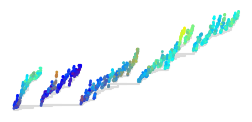

/opt/hostedtoolcache/Python/3.11.15/x64/lib/python3.11/site-packages/phyloframe/legacy/_alifestd_warn_topological_sensitivity.py:35: UserWarning: alifestd_collapse_unifurcations performs delete/update operations that do not update topology-dependent columns, which may be invalidated: ['num_leaves', 'num_children']. Use `origin_time` to recalculate branch lengths for collapsed phylogeny. To silence this warning, use alifestd_drop_topological_sensitivity{_polars} or set HSTRAT_ALIFESTD_WARN_TOPOLOGICAL_SENSITIVITY_SUPPRESS environment variable.
  warnings.warn(


teeplots/2026-03-04-fossil-clade/layout=horizontal+regime=sweep+seed=3+viz=draw-ctree+x=x+y=y+ext=.pdf
teeplots/2026-03-04-fossil-clade/layout=horizontal+regime=sweep+seed=3+viz=draw-ctree+x=x+y=y+ext=.png


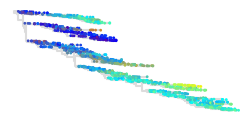

/opt/hostedtoolcache/Python/3.11.15/x64/lib/python3.11/site-packages/phyloframe/legacy/_alifestd_warn_topological_sensitivity.py:35: UserWarning: alifestd_collapse_unifurcations performs delete/update operations that do not update topology-dependent columns, which may be invalidated: ['num_leaves', 'num_children']. Use `origin_time` to recalculate branch lengths for collapsed phylogeny. To silence this warning, use alifestd_drop_topological_sensitivity{_polars} or set HSTRAT_ALIFESTD_WARN_TOPOLOGICAL_SENSITIVITY_SUPPRESS environment variable.
  warnings.warn(


teeplots/2026-03-04-fossil-clade/layout=radial+regime=sweep+seed=3+viz=draw-ctree+x=x+y=y+ext=.pdf
teeplots/2026-03-04-fossil-clade/layout=radial+regime=sweep+seed=3+viz=draw-ctree+x=x+y=y+ext=.png


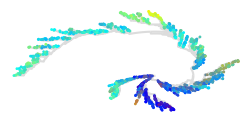

teeplots/2026-03-04-fossil-clade/cmap=bcyr+regime=sweep+seed=3+viz=draw-cscatter+x=x+y=y+ext=.pdf
teeplots/2026-03-04-fossil-clade/cmap=bcyr+regime=sweep+seed=3+viz=draw-cscatter+x=x+y=y+ext=.png


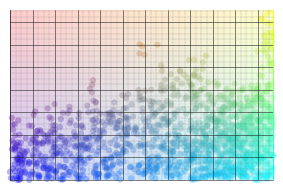

/opt/hostedtoolcache/Python/3.11.15/x64/lib/python3.11/site-packages/phyloframe/legacy/_alifestd_warn_topological_sensitivity.py:35: UserWarning: alifestd_prune_extinct_lineages_asexual performs delete operations that do not update topology-dependent columns, which may be invalidated: ['num_leaves']. Use `origin_time` to recalculate branch lengths for collapsed phylogeny. To silence this warning, use alifestd_drop_topological_sensitivity{_polars} or set HSTRAT_ALIFESTD_WARN_TOPOLOGICAL_SENSITIVITY_SUPPRESS environment variable.
  warnings.warn(
/opt/hostedtoolcache/Python/3.11.15/x64/lib/python3.11/site-packages/phyloframe/legacy/_alifestd_warn_topological_sensitivity.py:35: UserWarning: alifestd_collapse_unifurcations performs delete/update operations that do not update topology-dependent columns, which may be invalidated: ['num_leaves']. Use `origin_time` to recalculate branch lengths for collapsed phylogeny. To silence this warning, use alifestd_drop_topological_sensitivity{_polars}

teeplots/2026-03-04-fossil-clade/layout=vertical+regime=sweep+seed=4+viz=draw-ctree+x=x+y=y+ext=.pdf
teeplots/2026-03-04-fossil-clade/layout=vertical+regime=sweep+seed=4+viz=draw-ctree+x=x+y=y+ext=.png


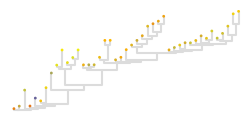

/opt/hostedtoolcache/Python/3.11.15/x64/lib/python3.11/site-packages/phyloframe/legacy/_alifestd_warn_topological_sensitivity.py:35: UserWarning: alifestd_collapse_unifurcations performs delete/update operations that do not update topology-dependent columns, which may be invalidated: ['num_leaves', 'num_children']. Use `origin_time` to recalculate branch lengths for collapsed phylogeny. To silence this warning, use alifestd_drop_topological_sensitivity{_polars} or set HSTRAT_ALIFESTD_WARN_TOPOLOGICAL_SENSITIVITY_SUPPRESS environment variable.
  warnings.warn(


teeplots/2026-03-04-fossil-clade/layout=horizontal+regime=sweep+seed=4+viz=draw-ctree+x=x+y=y+ext=.pdf
teeplots/2026-03-04-fossil-clade/layout=horizontal+regime=sweep+seed=4+viz=draw-ctree+x=x+y=y+ext=.png


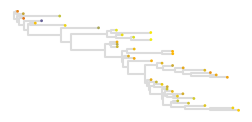

/opt/hostedtoolcache/Python/3.11.15/x64/lib/python3.11/site-packages/phyloframe/legacy/_alifestd_warn_topological_sensitivity.py:35: UserWarning: alifestd_collapse_unifurcations performs delete/update operations that do not update topology-dependent columns, which may be invalidated: ['num_leaves', 'num_children']. Use `origin_time` to recalculate branch lengths for collapsed phylogeny. To silence this warning, use alifestd_drop_topological_sensitivity{_polars} or set HSTRAT_ALIFESTD_WARN_TOPOLOGICAL_SENSITIVITY_SUPPRESS environment variable.
  warnings.warn(


teeplots/2026-03-04-fossil-clade/layout=radial+regime=sweep+seed=4+viz=draw-ctree+x=x+y=y+ext=.pdf
teeplots/2026-03-04-fossil-clade/layout=radial+regime=sweep+seed=4+viz=draw-ctree+x=x+y=y+ext=.png


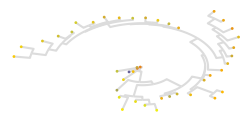

teeplots/2026-03-04-fossil-clade/cmap=bcyr+regime=sweep+seed=4+viz=draw-cscatter+x=x+y=y+ext=.pdf
teeplots/2026-03-04-fossil-clade/cmap=bcyr+regime=sweep+seed=4+viz=draw-cscatter+x=x+y=y+ext=.png


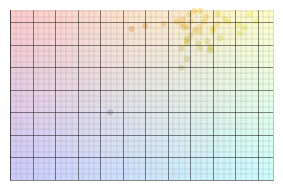

/opt/hostedtoolcache/Python/3.11.15/x64/lib/python3.11/site-packages/phyloframe/legacy/_alifestd_warn_topological_sensitivity.py:35: UserWarning: alifestd_prune_extinct_lineages_asexual performs delete operations that do not update topology-dependent columns, which may be invalidated: ['num_leaves']. Use `origin_time` to recalculate branch lengths for collapsed phylogeny. To silence this warning, use alifestd_drop_topological_sensitivity{_polars} or set HSTRAT_ALIFESTD_WARN_TOPOLOGICAL_SENSITIVITY_SUPPRESS environment variable.
  warnings.warn(
/opt/hostedtoolcache/Python/3.11.15/x64/lib/python3.11/site-packages/phyloframe/legacy/_alifestd_warn_topological_sensitivity.py:35: UserWarning: alifestd_collapse_unifurcations performs delete/update operations that do not update topology-dependent columns, which may be invalidated: ['num_leaves']. Use `origin_time` to recalculate branch lengths for collapsed phylogeny. To silence this warning, use alifestd_drop_topological_sensitivity{_polars}

teeplots/2026-03-04-fossil-clade/layout=vertical+regime=sweep+seed=5+viz=draw-ctree+x=x+y=y+ext=.pdf
teeplots/2026-03-04-fossil-clade/layout=vertical+regime=sweep+seed=5+viz=draw-ctree+x=x+y=y+ext=.png


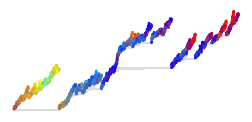

/opt/hostedtoolcache/Python/3.11.15/x64/lib/python3.11/site-packages/phyloframe/legacy/_alifestd_warn_topological_sensitivity.py:35: UserWarning: alifestd_collapse_unifurcations performs delete/update operations that do not update topology-dependent columns, which may be invalidated: ['num_leaves', 'num_children']. Use `origin_time` to recalculate branch lengths for collapsed phylogeny. To silence this warning, use alifestd_drop_topological_sensitivity{_polars} or set HSTRAT_ALIFESTD_WARN_TOPOLOGICAL_SENSITIVITY_SUPPRESS environment variable.
  warnings.warn(


teeplots/2026-03-04-fossil-clade/layout=horizontal+regime=sweep+seed=5+viz=draw-ctree+x=x+y=y+ext=.pdf
teeplots/2026-03-04-fossil-clade/layout=horizontal+regime=sweep+seed=5+viz=draw-ctree+x=x+y=y+ext=.png


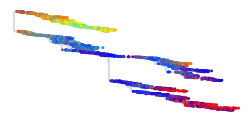

/opt/hostedtoolcache/Python/3.11.15/x64/lib/python3.11/site-packages/phyloframe/legacy/_alifestd_warn_topological_sensitivity.py:35: UserWarning: alifestd_collapse_unifurcations performs delete/update operations that do not update topology-dependent columns, which may be invalidated: ['num_leaves', 'num_children']. Use `origin_time` to recalculate branch lengths for collapsed phylogeny. To silence this warning, use alifestd_drop_topological_sensitivity{_polars} or set HSTRAT_ALIFESTD_WARN_TOPOLOGICAL_SENSITIVITY_SUPPRESS environment variable.
  warnings.warn(


teeplots/2026-03-04-fossil-clade/layout=radial+regime=sweep+seed=5+viz=draw-ctree+x=x+y=y+ext=.pdf
teeplots/2026-03-04-fossil-clade/layout=radial+regime=sweep+seed=5+viz=draw-ctree+x=x+y=y+ext=.png


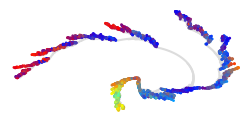

teeplots/2026-03-04-fossil-clade/cmap=bcyr+regime=sweep+seed=5+viz=draw-cscatter+x=x+y=y+ext=.pdf
teeplots/2026-03-04-fossil-clade/cmap=bcyr+regime=sweep+seed=5+viz=draw-cscatter+x=x+y=y+ext=.png


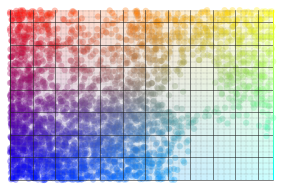

/opt/hostedtoolcache/Python/3.11.15/x64/lib/python3.11/site-packages/phyloframe/legacy/_alifestd_warn_topological_sensitivity.py:35: UserWarning: alifestd_prune_extinct_lineages_asexual performs delete operations that do not update topology-dependent columns, which may be invalidated: ['num_leaves']. Use `origin_time` to recalculate branch lengths for collapsed phylogeny. To silence this warning, use alifestd_drop_topological_sensitivity{_polars} or set HSTRAT_ALIFESTD_WARN_TOPOLOGICAL_SENSITIVITY_SUPPRESS environment variable.
  warnings.warn(
/opt/hostedtoolcache/Python/3.11.15/x64/lib/python3.11/site-packages/phyloframe/legacy/_alifestd_warn_topological_sensitivity.py:35: UserWarning: alifestd_collapse_unifurcations performs delete/update operations that do not update topology-dependent columns, which may be invalidated: ['num_leaves']. Use `origin_time` to recalculate branch lengths for collapsed phylogeny. To silence this warning, use alifestd_drop_topological_sensitivity{_polars}

teeplots/2026-03-04-fossil-clade/layout=vertical+regime=sweep+seed=6+viz=draw-ctree+x=x+y=y+ext=.pdf
teeplots/2026-03-04-fossil-clade/layout=vertical+regime=sweep+seed=6+viz=draw-ctree+x=x+y=y+ext=.png


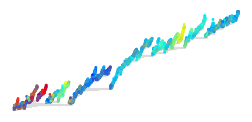

/opt/hostedtoolcache/Python/3.11.15/x64/lib/python3.11/site-packages/phyloframe/legacy/_alifestd_warn_topological_sensitivity.py:35: UserWarning: alifestd_collapse_unifurcations performs delete/update operations that do not update topology-dependent columns, which may be invalidated: ['num_leaves', 'num_children']. Use `origin_time` to recalculate branch lengths for collapsed phylogeny. To silence this warning, use alifestd_drop_topological_sensitivity{_polars} or set HSTRAT_ALIFESTD_WARN_TOPOLOGICAL_SENSITIVITY_SUPPRESS environment variable.
  warnings.warn(


teeplots/2026-03-04-fossil-clade/layout=horizontal+regime=sweep+seed=6+viz=draw-ctree+x=x+y=y+ext=.pdf
teeplots/2026-03-04-fossil-clade/layout=horizontal+regime=sweep+seed=6+viz=draw-ctree+x=x+y=y+ext=.png


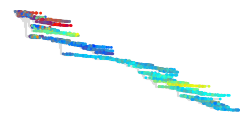

/opt/hostedtoolcache/Python/3.11.15/x64/lib/python3.11/site-packages/phyloframe/legacy/_alifestd_warn_topological_sensitivity.py:35: UserWarning: alifestd_collapse_unifurcations performs delete/update operations that do not update topology-dependent columns, which may be invalidated: ['num_leaves', 'num_children']. Use `origin_time` to recalculate branch lengths for collapsed phylogeny. To silence this warning, use alifestd_drop_topological_sensitivity{_polars} or set HSTRAT_ALIFESTD_WARN_TOPOLOGICAL_SENSITIVITY_SUPPRESS environment variable.
  warnings.warn(


teeplots/2026-03-04-fossil-clade/layout=radial+regime=sweep+seed=6+viz=draw-ctree+x=x+y=y+ext=.pdf
teeplots/2026-03-04-fossil-clade/layout=radial+regime=sweep+seed=6+viz=draw-ctree+x=x+y=y+ext=.png


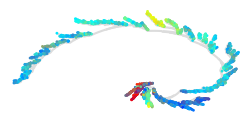

teeplots/2026-03-04-fossil-clade/cmap=bcyr+regime=sweep+seed=6+viz=draw-cscatter+x=x+y=y+ext=.pdf
teeplots/2026-03-04-fossil-clade/cmap=bcyr+regime=sweep+seed=6+viz=draw-cscatter+x=x+y=y+ext=.png


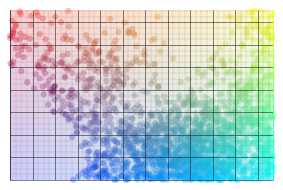

/opt/hostedtoolcache/Python/3.11.15/x64/lib/python3.11/site-packages/phyloframe/legacy/_alifestd_warn_topological_sensitivity.py:35: UserWarning: alifestd_prune_extinct_lineages_asexual performs delete operations that do not update topology-dependent columns, which may be invalidated: ['num_leaves']. Use `origin_time` to recalculate branch lengths for collapsed phylogeny. To silence this warning, use alifestd_drop_topological_sensitivity{_polars} or set HSTRAT_ALIFESTD_WARN_TOPOLOGICAL_SENSITIVITY_SUPPRESS environment variable.
  warnings.warn(
/opt/hostedtoolcache/Python/3.11.15/x64/lib/python3.11/site-packages/phyloframe/legacy/_alifestd_warn_topological_sensitivity.py:35: UserWarning: alifestd_collapse_unifurcations performs delete/update operations that do not update topology-dependent columns, which may be invalidated: ['num_leaves']. Use `origin_time` to recalculate branch lengths for collapsed phylogeny. To silence this warning, use alifestd_drop_topological_sensitivity{_polars}

teeplots/2026-03-04-fossil-clade/layout=vertical+regime=sweep+seed=7+viz=draw-ctree+x=x+y=y+ext=.pdf
teeplots/2026-03-04-fossil-clade/layout=vertical+regime=sweep+seed=7+viz=draw-ctree+x=x+y=y+ext=.png


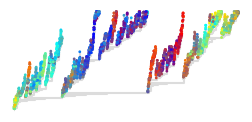

/opt/hostedtoolcache/Python/3.11.15/x64/lib/python3.11/site-packages/phyloframe/legacy/_alifestd_warn_topological_sensitivity.py:35: UserWarning: alifestd_collapse_unifurcations performs delete/update operations that do not update topology-dependent columns, which may be invalidated: ['num_leaves', 'num_children']. Use `origin_time` to recalculate branch lengths for collapsed phylogeny. To silence this warning, use alifestd_drop_topological_sensitivity{_polars} or set HSTRAT_ALIFESTD_WARN_TOPOLOGICAL_SENSITIVITY_SUPPRESS environment variable.
  warnings.warn(


teeplots/2026-03-04-fossil-clade/layout=horizontal+regime=sweep+seed=7+viz=draw-ctree+x=x+y=y+ext=.pdf
teeplots/2026-03-04-fossil-clade/layout=horizontal+regime=sweep+seed=7+viz=draw-ctree+x=x+y=y+ext=.png


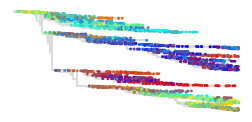

/opt/hostedtoolcache/Python/3.11.15/x64/lib/python3.11/site-packages/phyloframe/legacy/_alifestd_warn_topological_sensitivity.py:35: UserWarning: alifestd_collapse_unifurcations performs delete/update operations that do not update topology-dependent columns, which may be invalidated: ['num_leaves', 'num_children']. Use `origin_time` to recalculate branch lengths for collapsed phylogeny. To silence this warning, use alifestd_drop_topological_sensitivity{_polars} or set HSTRAT_ALIFESTD_WARN_TOPOLOGICAL_SENSITIVITY_SUPPRESS environment variable.
  warnings.warn(


teeplots/2026-03-04-fossil-clade/layout=radial+regime=sweep+seed=7+viz=draw-ctree+x=x+y=y+ext=.pdf
teeplots/2026-03-04-fossil-clade/layout=radial+regime=sweep+seed=7+viz=draw-ctree+x=x+y=y+ext=.png


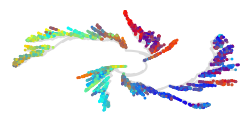

teeplots/2026-03-04-fossil-clade/cmap=bcyr+regime=sweep+seed=7+viz=draw-cscatter+x=x+y=y+ext=.pdf
teeplots/2026-03-04-fossil-clade/cmap=bcyr+regime=sweep+seed=7+viz=draw-cscatter+x=x+y=y+ext=.png


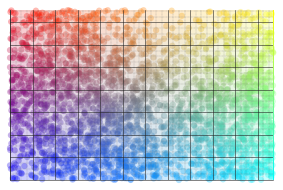

/opt/hostedtoolcache/Python/3.11.15/x64/lib/python3.11/site-packages/phyloframe/legacy/_alifestd_warn_topological_sensitivity.py:35: UserWarning: alifestd_prune_extinct_lineages_asexual performs delete operations that do not update topology-dependent columns, which may be invalidated: ['num_leaves']. Use `origin_time` to recalculate branch lengths for collapsed phylogeny. To silence this warning, use alifestd_drop_topological_sensitivity{_polars} or set HSTRAT_ALIFESTD_WARN_TOPOLOGICAL_SENSITIVITY_SUPPRESS environment variable.
  warnings.warn(
/opt/hostedtoolcache/Python/3.11.15/x64/lib/python3.11/site-packages/phyloframe/legacy/_alifestd_warn_topological_sensitivity.py:35: UserWarning: alifestd_collapse_unifurcations performs delete/update operations that do not update topology-dependent columns, which may be invalidated: ['num_leaves']. Use `origin_time` to recalculate branch lengths for collapsed phylogeny. To silence this warning, use alifestd_drop_topological_sensitivity{_polars}

teeplots/2026-03-04-fossil-clade/layout=vertical+regime=sweep+seed=8+viz=draw-ctree+x=x+y=y+ext=.pdf
teeplots/2026-03-04-fossil-clade/layout=vertical+regime=sweep+seed=8+viz=draw-ctree+x=x+y=y+ext=.png


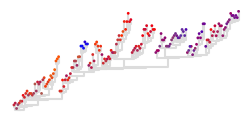

/opt/hostedtoolcache/Python/3.11.15/x64/lib/python3.11/site-packages/phyloframe/legacy/_alifestd_warn_topological_sensitivity.py:35: UserWarning: alifestd_collapse_unifurcations performs delete/update operations that do not update topology-dependent columns, which may be invalidated: ['num_leaves', 'num_children']. Use `origin_time` to recalculate branch lengths for collapsed phylogeny. To silence this warning, use alifestd_drop_topological_sensitivity{_polars} or set HSTRAT_ALIFESTD_WARN_TOPOLOGICAL_SENSITIVITY_SUPPRESS environment variable.
  warnings.warn(


teeplots/2026-03-04-fossil-clade/layout=horizontal+regime=sweep+seed=8+viz=draw-ctree+x=x+y=y+ext=.pdf
teeplots/2026-03-04-fossil-clade/layout=horizontal+regime=sweep+seed=8+viz=draw-ctree+x=x+y=y+ext=.png


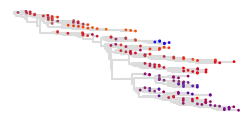

/opt/hostedtoolcache/Python/3.11.15/x64/lib/python3.11/site-packages/phyloframe/legacy/_alifestd_warn_topological_sensitivity.py:35: UserWarning: alifestd_collapse_unifurcations performs delete/update operations that do not update topology-dependent columns, which may be invalidated: ['num_leaves', 'num_children']. Use `origin_time` to recalculate branch lengths for collapsed phylogeny. To silence this warning, use alifestd_drop_topological_sensitivity{_polars} or set HSTRAT_ALIFESTD_WARN_TOPOLOGICAL_SENSITIVITY_SUPPRESS environment variable.
  warnings.warn(


teeplots/2026-03-04-fossil-clade/layout=radial+regime=sweep+seed=8+viz=draw-ctree+x=x+y=y+ext=.pdf
teeplots/2026-03-04-fossil-clade/layout=radial+regime=sweep+seed=8+viz=draw-ctree+x=x+y=y+ext=.png


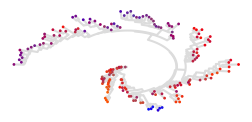

teeplots/2026-03-04-fossil-clade/cmap=bcyr+regime=sweep+seed=8+viz=draw-cscatter+x=x+y=y+ext=.pdf
teeplots/2026-03-04-fossil-clade/cmap=bcyr+regime=sweep+seed=8+viz=draw-cscatter+x=x+y=y+ext=.png


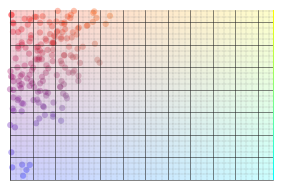

/opt/hostedtoolcache/Python/3.11.15/x64/lib/python3.11/site-packages/phyloframe/legacy/_alifestd_warn_topological_sensitivity.py:35: UserWarning: alifestd_prune_extinct_lineages_asexual performs delete operations that do not update topology-dependent columns, which may be invalidated: ['num_leaves']. Use `origin_time` to recalculate branch lengths for collapsed phylogeny. To silence this warning, use alifestd_drop_topological_sensitivity{_polars} or set HSTRAT_ALIFESTD_WARN_TOPOLOGICAL_SENSITIVITY_SUPPRESS environment variable.
  warnings.warn(
/opt/hostedtoolcache/Python/3.11.15/x64/lib/python3.11/site-packages/phyloframe/legacy/_alifestd_warn_topological_sensitivity.py:35: UserWarning: alifestd_collapse_unifurcations performs delete/update operations that do not update topology-dependent columns, which may be invalidated: ['num_leaves']. Use `origin_time` to recalculate branch lengths for collapsed phylogeny. To silence this warning, use alifestd_drop_topological_sensitivity{_polars}

teeplots/2026-03-04-fossil-clade/layout=vertical+regime=sweep+seed=9+viz=draw-ctree+x=x+y=y+ext=.pdf
teeplots/2026-03-04-fossil-clade/layout=vertical+regime=sweep+seed=9+viz=draw-ctree+x=x+y=y+ext=.png


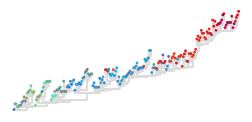

/opt/hostedtoolcache/Python/3.11.15/x64/lib/python3.11/site-packages/phyloframe/legacy/_alifestd_warn_topological_sensitivity.py:35: UserWarning: alifestd_collapse_unifurcations performs delete/update operations that do not update topology-dependent columns, which may be invalidated: ['num_leaves', 'num_children']. Use `origin_time` to recalculate branch lengths for collapsed phylogeny. To silence this warning, use alifestd_drop_topological_sensitivity{_polars} or set HSTRAT_ALIFESTD_WARN_TOPOLOGICAL_SENSITIVITY_SUPPRESS environment variable.
  warnings.warn(


teeplots/2026-03-04-fossil-clade/layout=horizontal+regime=sweep+seed=9+viz=draw-ctree+x=x+y=y+ext=.pdf
teeplots/2026-03-04-fossil-clade/layout=horizontal+regime=sweep+seed=9+viz=draw-ctree+x=x+y=y+ext=.png


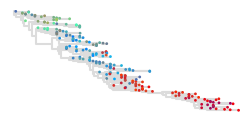

/opt/hostedtoolcache/Python/3.11.15/x64/lib/python3.11/site-packages/phyloframe/legacy/_alifestd_warn_topological_sensitivity.py:35: UserWarning: alifestd_collapse_unifurcations performs delete/update operations that do not update topology-dependent columns, which may be invalidated: ['num_leaves', 'num_children']. Use `origin_time` to recalculate branch lengths for collapsed phylogeny. To silence this warning, use alifestd_drop_topological_sensitivity{_polars} or set HSTRAT_ALIFESTD_WARN_TOPOLOGICAL_SENSITIVITY_SUPPRESS environment variable.
  warnings.warn(


teeplots/2026-03-04-fossil-clade/layout=radial+regime=sweep+seed=9+viz=draw-ctree+x=x+y=y+ext=.pdf
teeplots/2026-03-04-fossil-clade/layout=radial+regime=sweep+seed=9+viz=draw-ctree+x=x+y=y+ext=.png


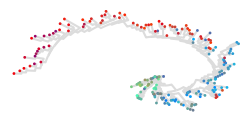

teeplots/2026-03-04-fossil-clade/cmap=bcyr+regime=sweep+seed=9+viz=draw-cscatter+x=x+y=y+ext=.pdf
teeplots/2026-03-04-fossil-clade/cmap=bcyr+regime=sweep+seed=9+viz=draw-cscatter+x=x+y=y+ext=.png


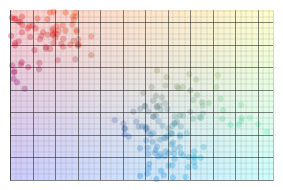

In [10]:
for regime, seed in it.product(
    ("pure", "sweep"),
    range(10),
):
    df = {
        "pure": df_pure,
        "sweep": df_sweep,
    }[regime]
    df = pfl.alifestd_downsample_tips_clade_asexual(
        df,
        n_downsample=3_000,
        seed=seed,
    )
    df = pfl.alifestd_collapse_unifurcations(df)
    df = pfl.alifestd_delete_unifurcating_roots_asexual(df)
    df["origin_time"] -= df["origin_time"].min()

    for layout in "vertical", "horizontal", "radial":

        with tp.teed(
            pylib.chloropleth.draw_ctree,
            df,
            x="x_",
            y="y_",
            cmap=pylib.cmap.bcyr.get_color,
            layout=layout,
            scatter_kws=dict(
                edgecolor="none",
                s=4,
            ),
            scatter_shuffle=1,
            tree_kws=dict(
                edge=dict(
                    color="gainsboro",
                    linewidth=0.5,
                ),
                margins=-0.05,
            ),
            teeplot_outattrs={"regime": regime, "seed": seed},
            teeplot_subdir=teeplot_subdir,
        ) as teed:
            teed.invert_yaxis()
            teed.figure.set_size_inches(3, 1.33)

    with tp.teed(
        pylib.chloropleth.draw_cscatter,
        df.dropna(subset=["x_", "y_"]),
        x="x",
        y="y",
        cmap=pylib.cmap.bcyr.get_color,
        despine=True,
        major=100,
        minor=25,
        xmax=1170,
        ymax=755,
        scatter_kws=dict(
            s=20,
        ),
        teeplot_outattrs={"cmap": "bcyr", "regime": regime, "seed": seed},
        teeplot_subdir=teeplot_subdir,
    ) as teed:
        teed.set_aspect("equal")
        fig = teed.figure
        fig.set_size_inches(3, 2)
        fig.tight_layout()
